> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib scipy


In [ ]:
# 中文字体：运行环境通常没有 CJK 字体，注册随仓库分发的思源黑体子集
import os, urllib.request, matplotlib, matplotlib.font_manager as fm
FONT = 'NotoSansCJKsc-Regular-subset.otf'
CAND = [FONT, os.path.join('..', 'assets', FONT), os.path.join('..', '..', 'assets', FONT),
        os.path.join('assets', FONT)]
URLS = [
    'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/assets/' + FONT,
    'https://gitee.com/tztgracious/copt-colab-cases/raw/main/assets/' + FONT,
]
path = next((p for p in CAND if os.path.exists(p)), None)
if path is None:
    for u in URLS:
        try:
            urllib.request.urlretrieve(u, FONT); path = FONT; break
        except Exception:
            continue
if path:
    fm.fontManager.addfont(path)
    matplotlib.rcParams['font.sans-serif'] = [fm.FontProperties(fname=path).get_name()]
    matplotlib.rcParams['axes.unicode_minus'] = False
    print('中文字体已就绪:', matplotlib.rcParams['font.sans-serif'][0])
else:
    print('未能加载中文字体，图表中的中文可能显示为方块')

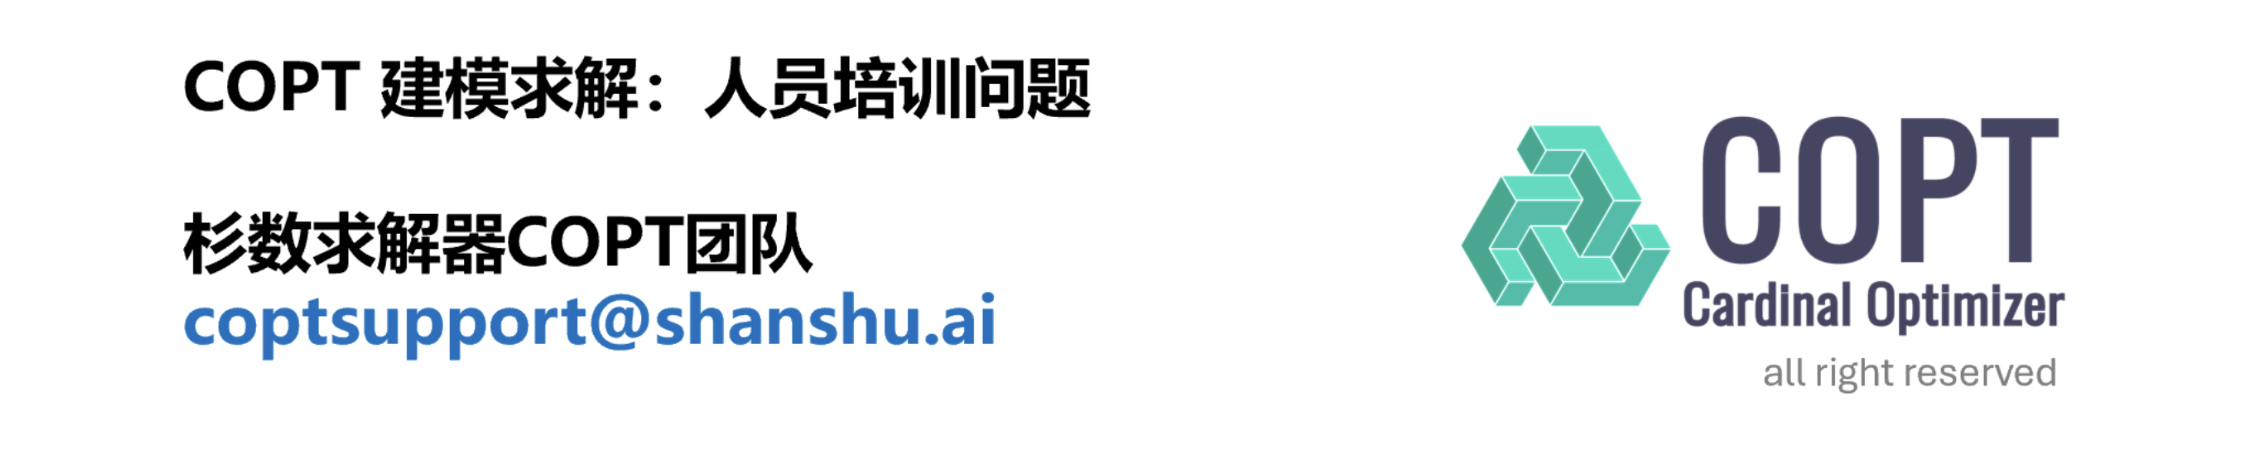

# 人员培训问题代码实现
## 使用COPT建模求解人员培训问题的步骤

1. **导入COPT-Python接口库** `coptpy`

2. **导入数据**
   - 组织模型参数，包括$c,d,u,v,m$以及序列数据$r_t,l_t$。
   - 明确时间索引集合$T=\{1,2,3,4,5,6\}$，并准备历史初始值（用于处理$y_{t-1},y_{t-2}$等跨期项）。

3. **创建COPT求解环境与模型**

4. **构建模型：依次添加三要素**
   - **决策变量**：
      - 为每个$t\in T$创建整数变量$x_t$，表示第$t$个月可用的正式空乘人员数量。
      - 为每个$t\in T$创建整数变量$y_t$，表示第$t$个月新招收的实习生数量，并设置上界为$m$。
   - **目标函数**：最小化总人员用工成本，为线性目标。
   - **约束条件**：
      - 空乘人员数量符合变化规律
      - 可用服务总时长不小于每个月需求时长

5. **求解**

6. 查看、分析**结果**

## 导入COPT-Python接口库

In [45]:
import coptpy as cp
from coptpy import COPT

from scipy.stats import norm
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

## 添加模型数据

In [47]:
# 空乘人员每月费用
c = 5100
# 实习生每月费用
d = 3600
# 空乘人员每月工作时长上限
u = 150
# 实习生每月工作时长上限
v = 25
# 每月最多招收实习生数量
m = 6
# 每个月航班时长需求
r = [8000, 9000, 9800, 9900, 10050, 10500]
# 每个月离职的空乘人员数量
l = [2, 0, 2, 0, 1, 0]
# 当期规划时间段
T = range(1, 7)          # 1..6
X = range(0, 7)      # 0..6
Y = range(-1, 7)      # -1..6

## 创建求解环境和求解模型

In [49]:
env = cp.Envr()
model_1 = env.createModel()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素

### 添加决策变量
- $x_t \geq 0$：第 $t$ 个月可用的空乘人员数量（位）
- $0 \leq y_t \leq m$：第 $t$ 个月新雇佣的实习生数量（位）

在本模型中，规划期内的月份采用从1开始的索引方式，其中$t=1$表示规划期的第一个月。

同时，允许使用下标为0和下标为负数的变量来表示规划期开始前的历史状态。具体而言，$x_0$表示规划期开始前可用的正式空乘人员数量，$y_0$和$y_{-1}$分别表示规划期开始前一个月和两个月新招收的实习生数量。

In [51]:
x = model_1.addVars(X, vtype=COPT.INTEGER, nameprefix='x')
y = model_1.addVars(Y, vtype=COPT.INTEGER, nameprefix='y')

## 初始条件的处理

在该多期人员规划模型中，部分历史状态在规划开始前已知。为避免引入不必要的等式约束，。为避免引入不必要的等式约束，并使模型结构更加简洁，这些已知初始状态通过设置变量的上下界直接固定，而不是额外添加约束条件。

具体而言，假设在规划开始前的历史状态已知：去年11月有2名实习生新入职，去年12月未新增实习生，且在去年12月末共有60名正式空乘人员在岗。在COPT代码实现中，可通过设置对应变量的下界和上界信息来刻画上述初始条件，例如：

In [53]:
x[0].lb = 60
x[0].ub = 60

y[-1].lb = 2
y[-1].ub = 2

y[0].lb = 0
y[0].ub = 0

通过这种方式，模型在求解过程中始终保持这些变量取值不变，从而将已知的历史状态自然融入多期决策模型中。这种处理方式不仅减少了模型中的显式约束数量，也有助于提升模型的可读性和求解效率，是多期规划问题中较为常见的工程实现方法。

### 设置目标函数
$$
    \min \sum_{t = 1} ^ 6 c \cdot x_t + d \cdot (y_t + y_{t-1})
$$

In [56]:
model_1.setObjective(
    cp.quicksum(c * x[t] + d * (y[t] + y[t-1]) for t in T),
    COPT.MINIMIZE
)

### 添加约束条件

1. 每个月的空乘人员数量服从变化规律（对应库存管理中的流守恒定律）

基于上述约定，空乘人员数量的动态平衡关系可分为以下两种情况描述：

- 对于规划期第一个月（$t=1$）：
$$
x_1 = x_0 + y_{-1}
$$

- 对于规划期内其余月份（$t=2,\dots,6$）：
$$
x_t = x_{t-1} - l_{t-1} + y_{t-2}, \quad t = 2,\dots,6
$$

上述约束用于刻画空乘人员规模在相邻月份之间的演化过程，反映了空乘人员离职以及实习生完成培训后转为正式空乘所带来的动态影响，是人员规划问题中典型的平衡约束形式。

In [59]:
model_1.addConstr(x[1] == x[0] + y[-1])
model_1.addConstrs(
    x[t] == x[t - 1] - l[t - 2] + y[t - 2]
    for t in T if t >= 2
)

2. 航班时长需求（对应库存管理中的禁止缺货）
$$
    u * x_t + v * (y_t + y_{t - 1}) \geq r_t, \quad \forall t
$$

In [61]:
model_1.addConstrs(u * x[t] + v * (y[t] + y[t - 1]) >= r[t-1] for t in T)

3. 每月招聘实习生数量限制（对应库存管理中进货量有限）
$$
    y_t \leq m, \quad \forall t
$$

In [63]:
model_1.addConstrs(y[t] <= m for t in T)

## 求解

In [65]:
model_1.solve()

Model fingerprint: cb0e4a9b

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    18 rows, 15 columns and 42 non-zero elements
    15 integers

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    5 rows, 6 columns and 17 non-zero elements
    6 integers

Problem info:
    Range of matrix coefficients:    [1e+00,2e+02]
    Range of rhs coefficients:       [4e+00,1e+04]
    Range of bound coefficients:     [6e+00,7e+01]
    Range of cost coefficients:      [4e+03,2e+04]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  1.965900e+06            --     Inf  0.04s
H        0         1      --       0  1.96

## 获取结果

Optimal total cost: 2077500.000000

Monthly trainee hiring plan and available flight attendants:


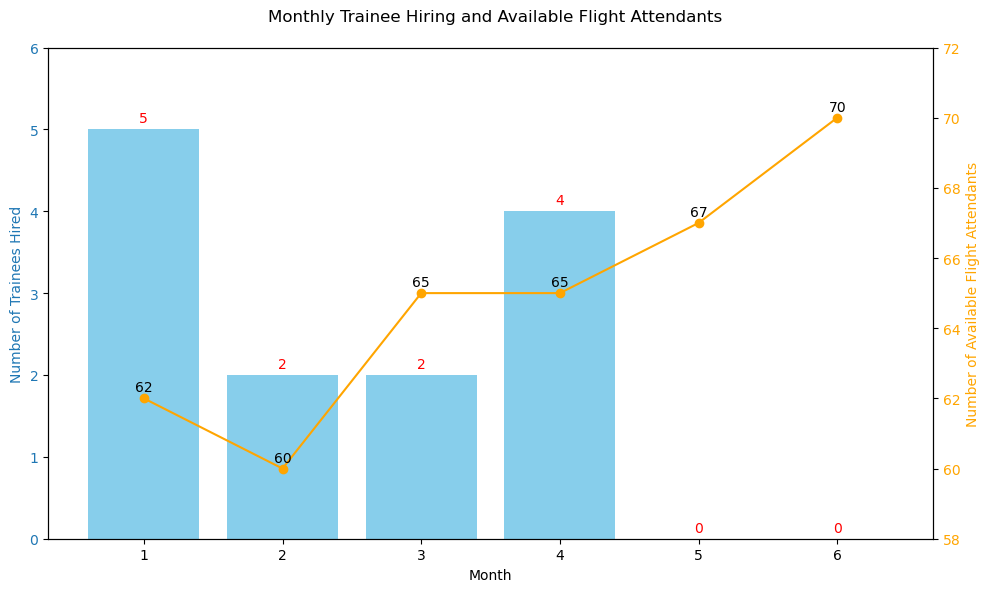

In [67]:
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt

if model_1.status == COPT.OPTIMAL:
    print(f'Optimal total cost: {model_1.objVal:0f}')
    print('\nMonthly trainee hiring plan and available flight attendants:')

    months = list(range(1,7))

    trainees = [int(y[t].x) for t in months]
    trainers = [int(x[t].x) for t in months]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Bar chart: trainees (left axis)
    ax1.bar(months, trainees, color='skyblue')
    ax1.set_xlabel('Month')
    ax1.set_ylabel('Number of Trainees Hired', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_ylim(0, max(trainees) + 1)
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Annotate bar values (trainees)
    for x_pos, val in zip(months, trainees):
        ax1.annotate(
            f'{val}',
            xy=(x_pos, val),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            color='red',
            fontsize=10
        )

    # Line chart: flight attendants (right axis)
    ax2 = ax1.twinx()
    ax2.plot(months, trainers, color='orange', marker='o')
    ax2.set_ylabel('Number of Available Flight Attendants', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2_min = min(trainers)
    ax2_max = max(trainers)
    ax2.set_ylim(ax2_min - 2, ax2_max + 2)
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Annotate line points
    for mon, val in zip(months, trainers):
        ax2.annotate(
            f'{val}',
            xy=(mon, val),
            xytext=(0, 5),
            textcoords='offset points',
            ha='center',
            fontsize=10
        )

    fig.suptitle('Monthly Trainee Hiring and Available Flight Attendants')
    plt.tight_layout()
    plt.show()
else:
    print('Optimal solution not found')


# 案例拓展：带有随机性的人员培训问题代码实现

在随机拓展模型中，整体建模框架与确定性模型保持一致，主要差异体现在输入参数的构造方式上。与将需求和人员流动视为固定值不同，本拓展问题中相关参数被视为具有统计特征的随机变量，从而在模型中显式刻画运营环境中的不确定性因素。

## 模型数据的构造与处理

在代码实现层面，随机拓展模型不再直接使用给定的需求值和离职人数，而是基于历史数据对其统计特性进行估计，假设其服从正态分布。具体而言，首先利用历史样本计算各月航班工作时长需求和空乘人员离职数量的均值与方差。在给定置信水平$1-\alpha$的条件下，通过计算相应的分位数，将随机变量转换为确定性的等价参数。由此得到的分位数值作为模型输入，用于替换原确定性模型中的$r_t$和$l_t$，从而构建一个在概率意义下满足运营需求和人员平衡要求的优化模型。

这种处理方式使得模型在保持整数规划结构不变的前提下，引入了对不确定性的风险控制机制。通过调节参数$\alpha$，可以灵活反映管理者对风险的容忍程度，在成本控制与服务保障之间实现合理权衡，也为随机环境下的人员招聘与培训决策提供了可操作的工程实现路径。


In [69]:
# Historical statistics (mean and variance)
r_mean = [8266, 8895, 9273, 9217, 9693, 10052]
r_var  = [1215, 1466, 1876, 1653, 1996, 2157]

l_mean = [1.15, 0.80, 1.30, 1.45, 0.85, 1.40]
l_var  = [0.57, 0.58, 0.73, 0.75, 0.50, 0.79]

# Risk level (confidence level = 1 - alpha)
alpha = 0.05
z_value = norm.ppf(1 - alpha)

# Quantile-based deterministic equivalents
r_hat = [
    r_mean[t] + z_value * math.sqrt(r_var[t])
    for t in range(6)
]

l_hat = [
    l_mean[t] + z_value * math.sqrt(l_var[t])
    for t in range(6)
]

print("Quantile-based demand (r_hat):\n", r_hat)
print("Quantile-based resignations (l_hat):\n", l_hat)

Quantile-based demand (r_hat):
 [8323.334416337188, 8957.97877978894, 9344.24324192429, 9283.874982838275, 9766.486493550683, 10128.392782581104]
Quantile-based resignations (l_hat):
 [2.391837255373821, 2.0526832015219725, 2.70536355491725, 2.874485026446947, 2.0130871536766737, 2.861977882437137]


## 创建求解模型

In [71]:
model_2 = env.createModel()

## 添加模型三要素

### 添加决策变量
- $x_t \geq 0$：第 $t$ 个月可用的空乘人员数量（位）
- $0 \leq y_t \leq m$：第 $t$ 个月新雇佣的实习生数量（位）


In [73]:
x = model_2.addVars(X, vtype = COPT.INTEGER, nameprefix = 'x')
y = model_2.addVars(Y, vtype = COPT.INTEGER, nameprefix = 'y')

In [74]:
x[0].lb = 60
x[0].ub = 60

y[-1].lb = 2
y[-1].ub = 2

y[0].lb = 0
y[0].ub = 0

### 设置目标函数
$$
    \min \sum_{t = 1} ^ 6 ( c \cdot x_t + d \cdot (y_t + y_{t-1}))
$$

In [76]:
model_2.setObjective(cp.quicksum(c * x[t] + d * (y[t] + y[t - 1]) for t in T))

### 添加约束条件
1. 每个月的空乘人员数量服从变化规律（对应库存管理中的流守恒定律）
$$
    x_{t - 1} - x_t + y_{t - 2} \geq \hat{l}_{t - 1}, \quad \forall t
$$


2. 航班时长需求（对应库存管理中的禁止缺货）
$$
    u * x_t + v * (y_t + y_{t - 1}) \geq \hat{r}_t, \quad \forall t
$$


3. 每月招聘实习生数量限制（对应库存管理中进货量有限）
$$
    y_t \leq m, \quad \forall t
$$

In [78]:
model_2.addConstr(x[0] - x[1] + y[-1] >= 0)
model_2.addConstrs(x[t - 1] - x[t] + y[t - 2] >= l_hat[t - 2] for t in T if t >= 2)
model_2.addConstrs(u * x[t] + v * (y[t] + y[t - 1]) >= r_hat[t - 1] for t in T)
model_2.addConstrs(y[t] <= m for t in T)

## 求解

In [80]:
model_2.solve()

Model fingerprint: 48beff90

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    18 rows, 15 columns and 42 non-zero elements
    15 integers

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    9 rows, 11 columns and 27 non-zero elements
    3 binaries and 8 integers

Problem info:
    Range of matrix coefficients:    [1e+00,2e+02]
    Range of rhs coefficients:       [1e+00,1e+04]
    Range of bound coefficients:     [1e+00,7e+01]
    Range of cost coefficients:      [4e+03,1e+04]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  1.964100e+06            --     Inf  0.04s
H        0         1      

## 获取结果

Optimal total cost: 2069400.000000

Monthly trainee hiring plan and available flight attendants:


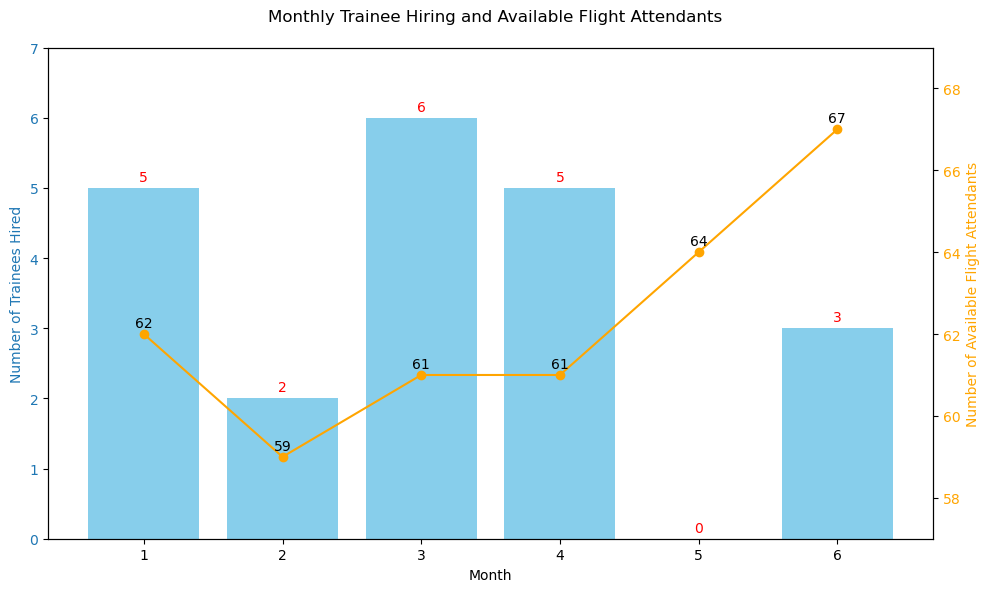

In [82]:
if model_2.status == COPT.OPTIMAL:
    print(f'Optimal total cost: {model_2.objVal:0f}')
    print('\nMonthly trainee hiring plan and available flight attendants:')

    months = list(range(1,7))

    trainees = [int(y[t].x) for t in months]
    trainers = [int(x[t].x) for t in months]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Bar chart: trainees (left axis)
    ax1.bar(months, trainees, color='skyblue')
    ax1.set_xlabel('Month')
    ax1.set_ylabel('Number of Trainees Hired', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_ylim(0, max(trainees) + 1)
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
    
    # Annotate bar values (trainees)
    for x_pos, val in zip(months, trainees):
        ax1.annotate(
            f'{val}',
            xy=(x_pos, val),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            color='red',
            fontsize=10
        )

    # Line chart: flight attendants (right axis)
    ax2 = ax1.twinx()
    ax2.plot(months, trainers, color='orange', marker='o')
    ax2.set_ylabel('Number of Available Flight Attendants', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2_min = min(trainers)
    ax2_max = max(trainers)
    ax2.set_ylim(ax2_min - 2, ax2_max + 2)
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Annotate line points
    for mon, val in zip(months, trainers):
        ax2.annotate(
            f'{val}',
            xy=(mon, val),
            xytext=(0, 5),
            textcoords='offset points',
            ha='center',
            fontsize=10
        )

    fig.suptitle('Monthly Trainee Hiring and Available Flight Attendants')
    plt.tight_layout()
    plt.show()
else:
    print('Optimal solution not found')
